# 6b — Benchmark SegFormer (MiT-B5)

**Projet 9 – Veille & Amélioration – Cityscapes 8 classes**

|                |                                                 |
| -------------- | ----------------------------------------------- |
| **Modèle**     | SegFormer avec encodeur MiT-B5                  |
| **Framework**  | TensorFlow / Keras via `keras-hub`              |
| **Résolution** | 256 × 256                                       |
| **Protocole**  | Identique notebooks ResNet50, ConvNeXt & MiT-B0 |
| **Loss**       | CE + 0.5 × Dice                                 |
| **Métrique**   | mIoU (classes 0-7, IGNORE=255)                  |

**MiT-B5** est la variante la plus lourde de la famille Mix Transformer (~82 M params encodeur).
Comparé à MiT-B0 (~3.8 M), B5 utilise des dimensions d'embedding plus larges et des blocs
d'attention plus profonds (depths [3, 6, 40, 3]), ce qui lui donne une capacité de représentation
nettement supérieure.

**Attention VRAM** : sur 1080 Ti (11 Go), le batch_size est réduit à **2** pour tenir en mémoire.

**Références** :

- Xie et al., _SegFormer: Simple and Efficient Design for Semantic Segmentation_, NeurIPS 2021 — https://arxiv.org/abs/2105.15203
- keras-hub `SegFormerBackbone` + `SegFormerImageSegmenter`

> **Prérequis** : `pip install keras-hub`


## 📁 Setup & imports


In [1]:
# os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"
# os.environ["XLA_FLAGS"] = "--xla_gpu_strict_conv_algorithm_picker=false"
# os.environ["TF_XLA_FLAGS"] = "--tf_xla_auto_jit=0"
# os.environ["TF_CUDNN_USE_AUTOTUNE"] = "0"

import os

os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"

os.environ["TF_USE_CUDNN_AUTOTUNE"] = "0"
os.environ["TF_CUDNN_USE_AUTOTUNE"] = "0"

# "1" si PB.
os.environ["TF_CUDNN_USE_FRONTEND"] = "0"

# Désactive le XLA auto-jit
os.environ["TF_XLA_FLAGS"] = "--tf_xla_auto_jit=0"

In [2]:
import sys
from pathlib import Path

ROOT = Path(".").resolve()
while not (ROOT / "scripts").exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))
print(f"ROOT = {ROOT}")

ROOT = /home/ui/PROJ9


In [3]:
import tensorflow as tf

tf.config.optimizer.set_jit(False)
tf.config.experimental.enable_op_determinism()

gpus = tf.config.list_physical_devices("GPU")
print("GPUs:", gpus)

if gpus:
    tf.config.set_logical_device_configuration(
        gpus[0], [tf.config.LogicalDeviceConfiguration(memory_limit=9000)]
    )

print("TF:", tf.__version__)

GPUs: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
TF: 2.20.0


In [4]:
import os, gc, json, time, random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

from tensorflow.keras import callbacks
import tensorflow.keras.backend as K

from scripts.config import CITYSCAPES_DIR, resolve_split_csv, EXP_DIR
from scripts.preprocessing import (
    N_CLASSES, IGNORE_LABEL, CATEGORY_NAMES, PALETTE, colorize_groups,
)
from scripts.datagen import CityscapesSequence
from scripts.augmentations import make_train_aug
from scripts.losses_metrics import dice_loss_sparse, MeanIoUArgmax
from scripts.models import segformer_mitb0, SegFormerPreprocess

print(f"TF {tf.__version__}")
print(f"GPU : {tf.config.list_physical_devices('GPU')}")

TF 2.20.0
GPU : [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


I0000 00:00:1773071694.895329 1292091 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 9000 MB memory:  -> device: 0, name: NVIDIA GeForce GTX 1080 Ti, pci bus id: 0000:07:00.0, compute capability: 6.1


## ⚙️ Hyperparamètres


In [5]:
# ──── Hyperparamètres ────
SEED            = 42
SIZE_HW         = (256, 256)
BATCH           = 4
EPOCHS          = 10         # Phase 1 : tête MLP seule (encoder gelé)
EPOCHS_FT       = 5         # Phase 2 : fine-tuning complet
LR              = 6e-5       # Phase 1
LR_FT           = 1e-5       # Phase 2
AUG             = True
AUG_REPEATS     = 1
PATIENCE        = 4
PATIENCE_FT     = 4

# ──── Encodeur MiT-B5 ────
ENCODER_PRESET    = "mit_b5_cityscapes_1024"
ENCODER_TRAINABLE = False    # Phase 1 gelé, Phase 2 dégelé

OUT_DIR = EXP_DIR
OUT_DIR.mkdir(parents=True, exist_ok=True)

RUN_NAME = (
    f"SEGFORMER_MITB5_{SIZE_HW[0]}x{SIZE_HW[1]}"
    f"_b{BATCH}_aug{int(AUG)}_rep{AUG_REPEATS}_ce_dice"
    f"_e{EPOCHS}ft{EPOCHS_FT}_seed{SEED}"
)
BEST_PATH    = OUT_DIR / f"{RUN_NAME}.keras"
RESULTS_JSON = OUT_DIR / f"{RUN_NAME}_results.json"
print("Run :", RUN_NAME)

Run : SEGFORMER_MITB5_256x256_b4_aug1_rep1_ce_dice_e10ft5_seed42


## 📂 Données


In [6]:
tf.random.set_seed(SEED); np.random.seed(SEED); random.seed(SEED)

df = pd.read_csv(resolve_split_csv())
train_df = df[df["split_final"] == "train"].copy()
val_df   = df[df["split_final"] == "val"].copy()
test_df  = df[df["split_final"] == "test"].copy()
print(f"Train : {len(train_df)}  |  Val : {len(val_df)}  |  Test : {len(test_df)}")

train_aug = make_train_aug() if AUG else None

train_seq = CityscapesSequence(train_df, base_dir=CITYSCAPES_DIR, batch_size=BATCH,
                               size_hw=SIZE_HW, augment=train_aug, shuffle=True, seed=SEED, aug_repeats=AUG_REPEATS)
val_seq   = CityscapesSequence(val_df,   base_dir=CITYSCAPES_DIR, batch_size=BATCH,
                               size_hw=SIZE_HW, augment=None, shuffle=False, seed=SEED)
test_seq  = CityscapesSequence(test_df,  base_dir=CITYSCAPES_DIR, batch_size=BATCH,
                               size_hw=SIZE_HW, augment=None, shuffle=False, seed=SEED)

print(f"Étapes — train: {len(train_seq)} | val: {len(val_seq)} | test: {len(test_seq)}")

Train : 2380  |  Val : 500  |  Test : 595
Étapes — train: 595 | val: 125 | test: 149


/home/ui/PROJ9/scripts/augmentations.py:15: UserWarning: Argument(s) 'var_limit' are not valid for transform GaussNoise
  A.GaussNoise(var_limit=(5.0, 20.0), p=0.2),
/home/ui/PROJ9/.env0/lib/python3.12/site-packages/albumentations/core/validation.py:114: UserWarning: ShiftScaleRotate is a special case of Affine transform. Please use Affine transform instead.
  original_init(self, **validated_kwargs)


## 🏗 Modèle SegFormer MiT-B5

Encodeur MiT-B5 gelé en phase 1, dégelé en phase 2.  
La tête MLP-Decoder (All-MLP) est toujours entraînable.

**MiT-B5** :

- Embedding dims : [64, 128, 320, 512]
- Depths : [3, 6, 40, 3] (40 blocs au stage 3 !)
- ~82 M params encodeur (vs ~3.8 M pour B0)


In [7]:
K.clear_session(); gc.collect()

model = segformer_mitb0(
    input_shape=(SIZE_HW[0], SIZE_HW[1], 3),
    n_classes=N_CLASSES,
    encoder_preset=ENCODER_PRESET,
    trainable=ENCODER_TRAINABLE,
    projection_filters=256,
)
model.summary(line_length=100, expand_nested=False)

n_train = sum(tf.size(v).numpy() for v in model.trainable_variables)
print(f"\nParams entraînables : {n_train:,}")

Model: "segformer_mitb0"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                               ┃ Output Shape                    ┃           Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ image_rgb_01 (InputLayer)                  │ (None, 256, 256, 3)             │                 0 │
├────────────────────────────────────────────┼─────────────────────────────────┼───────────────────┤
│ segformer_preprocess (SegFormerPreprocess) │ (None, 256, 256, 3)             │                 0 │
├────────────────────────────────────────────┼─────────────────────────────────┼───────────────────┤
│ seg_former_image_segmenter                 │ (None, 256, 256, 8)             │        81,971,400 │
│ (SegFormerImageSegmenter)                  │                                 │                   │
├────────────────────────────────────────────┼─────────────────────────────────┼───────────────────┤
│ probs (Softmax)                            │ (None, 256, 256, 8)             │                 0 │
└────────────────────────────────────────────┴─────────────────────────────────┴───────────────────┘

 Total params: 81,971,400 (312.70 MB)

 Trainable params: 527,880 (2.01 MB)

 Non-trainable params: 81,443,520 (310.68 MB)


Params entraînables : 527,880


## ⚗️ Phase 1 — Tête MLP seulement (encodeur MiT-B5 gelé)


In [8]:
def compile_model(m, lr):
    def loss_fn(y_true, y_pred):
        y_t   = tf.cast(tf.squeeze(y_true, axis=-1), tf.int32)
        valid = tf.not_equal(y_t, IGNORE_LABEL)
        y_s   = tf.where(valid, y_t, tf.zeros_like(y_t))
        ce    = tf.keras.losses.sparse_categorical_crossentropy(y_s, y_pred)
        ce    = tf.where(valid, ce, 0.0)
        denom = tf.reduce_sum(tf.cast(valid, tf.float32)) + 1e-6
        return tf.reduce_sum(ce) / denom + 0.5 * dice_loss_sparse(y_true, y_pred, n_classes=N_CLASSES)
    m.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=lr),
        loss=loss_fn,
        metrics=[MeanIoUArgmax(num_classes=N_CLASSES, name="mIoU")],
    )
    return m

In [9]:
model = compile_model(model, lr=LR)

cb1 = [
    callbacks.ModelCheckpoint(str(BEST_PATH), monitor="val_mIoU", mode="max",
                              save_best_only=True, verbose=1),
    callbacks.EarlyStopping(monitor="val_mIoU", mode="max", patience=PATIENCE,
                            restore_best_weights=True),
    callbacks.ReduceLROnPlateau(monitor="val_mIoU", mode="max", patience=4,
                                factor=0.5, min_lr=1e-6, verbose=1),
    callbacks.CSVLogger(str(OUT_DIR / f"{RUN_NAME}_phase1.csv")),
]

t0 = time.time()
hist1 = model.fit(train_seq, validation_data=val_seq, epochs=EPOCHS, callbacks=cb1, verbose=1)
t_ph1 = time.time() - t0
print(f"\nPhase 1 : {t_ph1/60:.1f} min")

Epoch 1/10


E0000 00:00:1773071749.180337 1292091 meta_optimizer.cc:967] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape inStatefulPartitionedCall/segformer_mitb0_1/seg_former_image_segmenter_1/dropout_104_1/stateless_dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer


595/595 ━━━━━━━━━━━━━━━━━━━━ 0s 504ms/step - loss: 1.2361 - mIoU: 0.4052
Epoch 1: val_mIoU improved from None to 0.65221, saving model to /home/ui/PROJ9/out/experiments/SEGFORMER_MITB5_256x256_b4_aug1_rep1_ce_dice_e10ft5_seed42.keras

Epoch 1: finished saving model to /home/ui/PROJ9/out/experiments/SEGFORMER_MITB5_256x256_b4_aug1_rep1_ce_dice_e10ft5_seed42.keras
595/595 ━━━━━━━━━━━━━━━━━━━━ 415s 622ms/step - loss: 0.8831 - mIoU: 0.4998 - val_loss: 0.5456 - val_mIoU: 0.6522 - learning_rate: 6.0000e-05
Epoch 2/10
595/595 ━━━━━━━━━━━━━━━━━━━━ 0s 497ms/step - loss: 0.6446 - mIoU: 0.6034
Epoch 2: val_mIoU improved from 0.65221 to 0.67308, saving model to /home/ui/PROJ9/out/experiments/SEGFORMER_MITB5_256x256_b4_aug1_rep1_ce_dice_e10ft5_seed42.keras

Epoch 2: finished saving model to /home/ui/PROJ9/out/experiments/SEGFORMER_MITB5_256x256_b4_aug1_rep1_ce_dice_e10ft5_seed42.keras
595/595 ━━━━━━━━━━━━━━━━━━━━ 356s 599ms/step - loss: 0.6250 - mIoU: 0.6111 - val_loss: 0.4969 - val_mIoU: 0.6731 - 

## 🔓 Phase 2 — Fine-tuning complet (MiT-B5 dégelé)


In [10]:
custom_objs = {"MeanIoUArgmax": MeanIoUArgmax, "dice_loss_sparse": dice_loss_sparse,
               "SegFormerPreprocess": SegFormerPreprocess}
model = tf.keras.models.load_model(str(BEST_PATH), custom_objects=custom_objs, compile=False)

for layer in model.layers:
    layer.trainable = True

model = compile_model(model, lr=LR_FT)

n_train_ft = sum(tf.size(v).numpy() for v in model.trainable_variables)
print(f"Params entraînables (fine-tune) : {n_train_ft:,}")

cb2 = [
    callbacks.ModelCheckpoint(str(BEST_PATH), monitor="val_mIoU", mode="max",
                              save_best_only=True, verbose=1),
    callbacks.EarlyStopping(monitor="val_mIoU", mode="max", patience=PATIENCE_FT,
                            restore_best_weights=True),
    callbacks.ReduceLROnPlateau(monitor="val_mIoU", mode="max", patience=4,
                                factor=0.5, min_lr=1e-7, verbose=1),
    callbacks.CSVLogger(str(OUT_DIR / f"{RUN_NAME}_phase2.csv")),
]

t0 = time.time()
hist2 = model.fit(train_seq, validation_data=val_seq, epochs=EPOCHS_FT, callbacks=cb2, verbose=1)
t_ph2 = time.time() - t0
t_tot = t_ph1 + t_ph2
print(f"\nPhase 2 : {t_ph2/60:.1f} min  |  Total : {t_tot/60:.1f} min")

/home/ui/PROJ9/.env0/lib/python3.12/site-packages/keras/src/saving/serialization_lib.py:749: UserWarning: `compile()` was not called as part of model loading because the model's `compile()` method is custom. All subclassed Models that have `compile()` overridden should also override `get_compile_config()` and `compile_from_config(config)`. Alternatively, you can call `compile()` manually after loading.
  instance.compile_from_config(compile_config)


Params entraînables (fine-tune) : 81,970,888
Epoch 1/5


E0000 00:00:1773075564.012504 1292091 meta_optimizer.cc:967] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape inStatefulPartitionedCall/segformer_mitb0_1/seg_former_image_segmenter_1/dropout_209_1/stateless_dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer
W0000 00:00:1773075587.593402 1292206 conv_ops_gpu.cc:328] None of the algorithms provided by cuDNN frontend heuristics worked; trying fallback algorithms.  Conv: batch: 4
in_depths: 128
out_depths: 320
in: 34
in: 34
data_format: 1
filter: 3
filter: 3
filter: 128
dilation: 1
dilation: 1
stride: 2
stride: 2
padding: 0
padding: 0
dtype: DT_FLOAT
group_count: 1
device_identifier: "sm_6.1 with 11811028992B RAM, 28 cores, 1721000KHz clock, 5505000KHz mem clock, 2883584B L2$"
version: 3

W0000 00:00:1773075587.769247 1292206 conv_ops_gpu.cc:328] None of the algorithms provided by cuDNN frontend heuristics worked; trying fallback algorithms.  Conv: batch: 4
in_depths: 64
out_depths: 1

595/595 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - loss: 0.4955 - mIoU: 0.6662
Epoch 1: val_mIoU improved from None to 0.71139, saving model to /home/ui/PROJ9/out/experiments/SEGFORMER_MITB5_256x256_b4_aug1_rep1_ce_dice_e10ft5_seed42.keras

Epoch 1: finished saving model to /home/ui/PROJ9/out/experiments/SEGFORMER_MITB5_256x256_b4_aug1_rep1_ce_dice_e10ft5_seed42.keras
595/595 ━━━━━━━━━━━━━━━━━━━━ 1180s 2s/step - loss: 0.4753 - mIoU: 0.6756 - val_loss: 0.4079 - val_mIoU: 0.7114 - learning_rate: 1.0000e-05
Epoch 2/5
595/595 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - loss: 0.4450 - mIoU: 0.6908
Epoch 2: val_mIoU improved from 0.71139 to 0.71527, saving model to /home/ui/PROJ9/out/experiments/SEGFORMER_MITB5_256x256_b4_aug1_rep1_ce_dice_e10ft5_seed42.keras

Epoch 2: finished saving model to /home/ui/PROJ9/out/experiments/SEGFORMER_MITB5_256x256_b4_aug1_rep1_ce_dice_e10ft5_seed42.keras
595/595 ━━━━━━━━━━━━━━━━━━━━ 995s 2s/step - loss: 0.4476 - mIoU: 0.6886 - val_loss: 0.4008 - val_mIoU: 0.7153 - learning_rat

## 📊 Évaluation finale


In [11]:
# Recharger le meilleur modèle
model = tf.keras.models.load_model(str(BEST_PATH), custom_objects=custom_objs, compile=False)
model = compile_model(model, lr=LR_FT)

val_res  = model.evaluate(val_seq,  verbose=1)
test_res = model.evaluate(test_seq, verbose=1)

print(f"\n{'='*50}")
print(f"  SegFormer MiT-B5  —  {SIZE_HW[0]}x{SIZE_HW[1]}")
print(f"{'='*50}")
print(f"  Val  loss={val_res[0]:.4f}   mIoU={val_res[1]:.4f}")
print(f"  Test loss={test_res[0]:.4f}   mIoU={test_res[1]:.4f}")

125/125 ━━━━━━━━━━━━━━━━━━━━ 68s 458ms/step - loss: 0.3872 - mIoU: 0.7213
149/149 ━━━━━━━━━━━━━━━━━━━━ 73s 489ms/step - loss: 0.3503 - mIoU: 0.7364

  SegFormer MiT-B5  —  256x256
  Val  loss=0.3872   mIoU=0.7213
  Test loss=0.3503   mIoU=0.7364


## 📈 IoU par classe


In [12]:
# Calcul IoU par classe sur test set
from tensorflow.keras.metrics import MeanIoU

m_iou = MeanIoU(num_classes=N_CLASSES)

for i in range(len(test_seq)):
    X, y = test_seq[i]
    preds = np.argmax(model.predict(X, verbose=0), axis=-1)
    y_flat = y[..., 0].astype(np.int32)
    valid = y_flat != IGNORE_LABEL
    m_iou.update_state(y_flat[valid], preds[valid])

cm = m_iou.total_cm.numpy()
per_class_iou = np.zeros(N_CLASSES)
for c in range(N_CLASSES):
    tp = cm[c, c]
    fp = cm[:, c].sum() - tp
    fn = cm[c, :].sum() - tp
    per_class_iou[c] = tp / (tp + fp + fn + 1e-8)

miou_manual = per_class_iou.mean()
print(f"\nmIoU (test, manuel) = {miou_manual:.4f}")
for i, name in enumerate(CATEGORY_NAMES):
    print(f"  {name:15s} : {per_class_iou[i]:.4f}")

2026-03-09 19:26:21.414239: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_14}}
2026-03-09 19:26:28.201585: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),


mIoU (test, manuel) = 0.7364
  void            : 0.6687
  flat            : 0.9523
  construction    : 0.8225
  object          : 0.3239
  nature          : 0.8349
  sky             : 0.8793
  human           : 0.5709
  vehicle         : 0.8388


## 📉 Courbes d'entraînement & résumé visuel


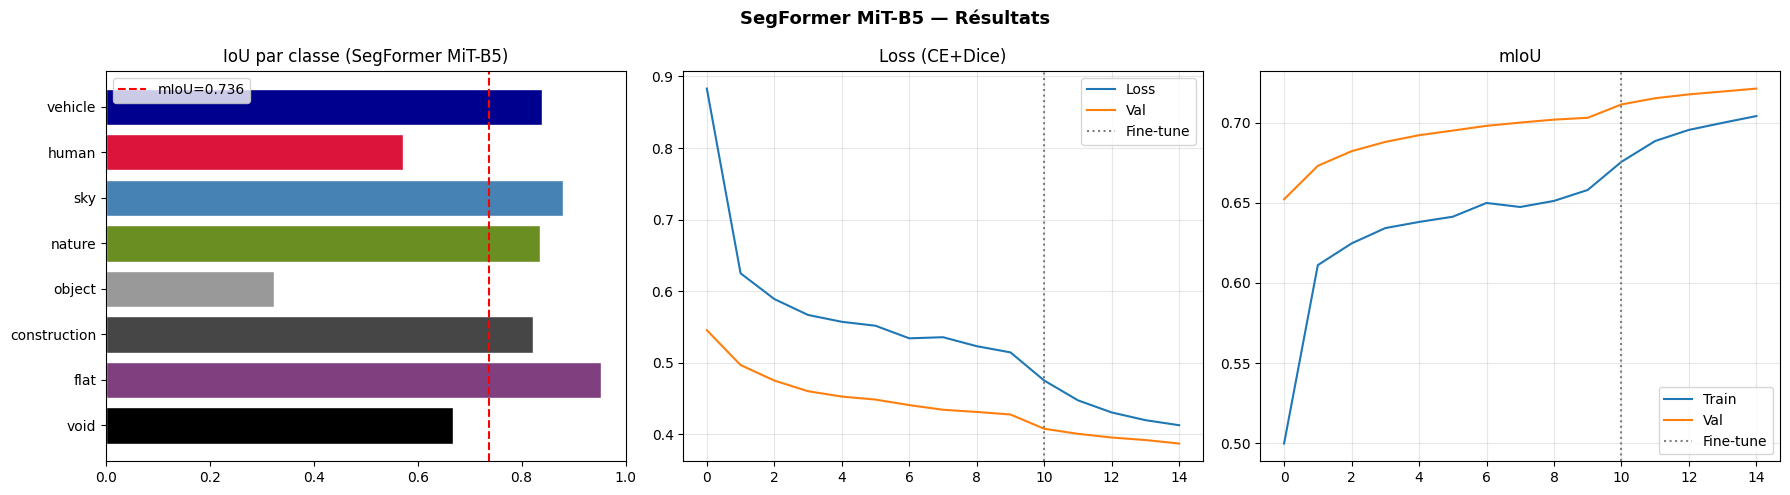

In [13]:
# Combiner historiques phase 1 + phase 2
all_loss  = hist1.history["loss"]  + hist2.history["loss"]
all_vloss = hist1.history["val_loss"] + hist2.history["val_loss"]
all_iou   = hist1.history["mIoU"]  + hist2.history["mIoU"]
all_viou  = hist1.history["val_mIoU"] + hist2.history["val_mIoU"]
ep_split  = len(hist1.history["loss"])

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# IoU par classe
colors = [tuple(c/255 for c in PALETTE[i]) for i in range(N_CLASSES)]
axes[0].barh(CATEGORY_NAMES, per_class_iou, color=colors, edgecolor="white")
axes[0].axvline(miou_manual, color="red", linestyle="--", label=f"mIoU={miou_manual:.3f}")
axes[0].set_xlim(0, 1); axes[0].set_title("IoU par classe (SegFormer MiT-B5)"); axes[0].legend()

# Loss
axes[1].plot(all_loss,  label="Loss"); axes[1].plot(all_vloss, label="Val")
axes[1].axvline(ep_split, color="grey", linestyle=":", label="Fine-tune")
axes[1].set_title("Loss (CE+Dice)"); axes[1].legend(); axes[1].grid(alpha=0.3)

# mIoU
axes[2].plot(all_iou,  label="Train"); axes[2].plot(all_viou, label="Val")
axes[2].axvline(ep_split, color="grey", linestyle=":", label="Fine-tune")
axes[2].set_title("mIoU"); axes[2].legend(); axes[2].grid(alpha=0.3)

plt.suptitle("SegFormer MiT-B5 — Résultats", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(str(OUT_DIR / f"{RUN_NAME}_summary.png"), dpi=120)
plt.show()

## 🔍 Prédictions qualitatives


2026-03-09 19:27:54.803108: E tensorflow/core/framework/node_def_util.cc:680] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be ignored. NodeDef: {{node ParallelMapDatasetV2/_14}}


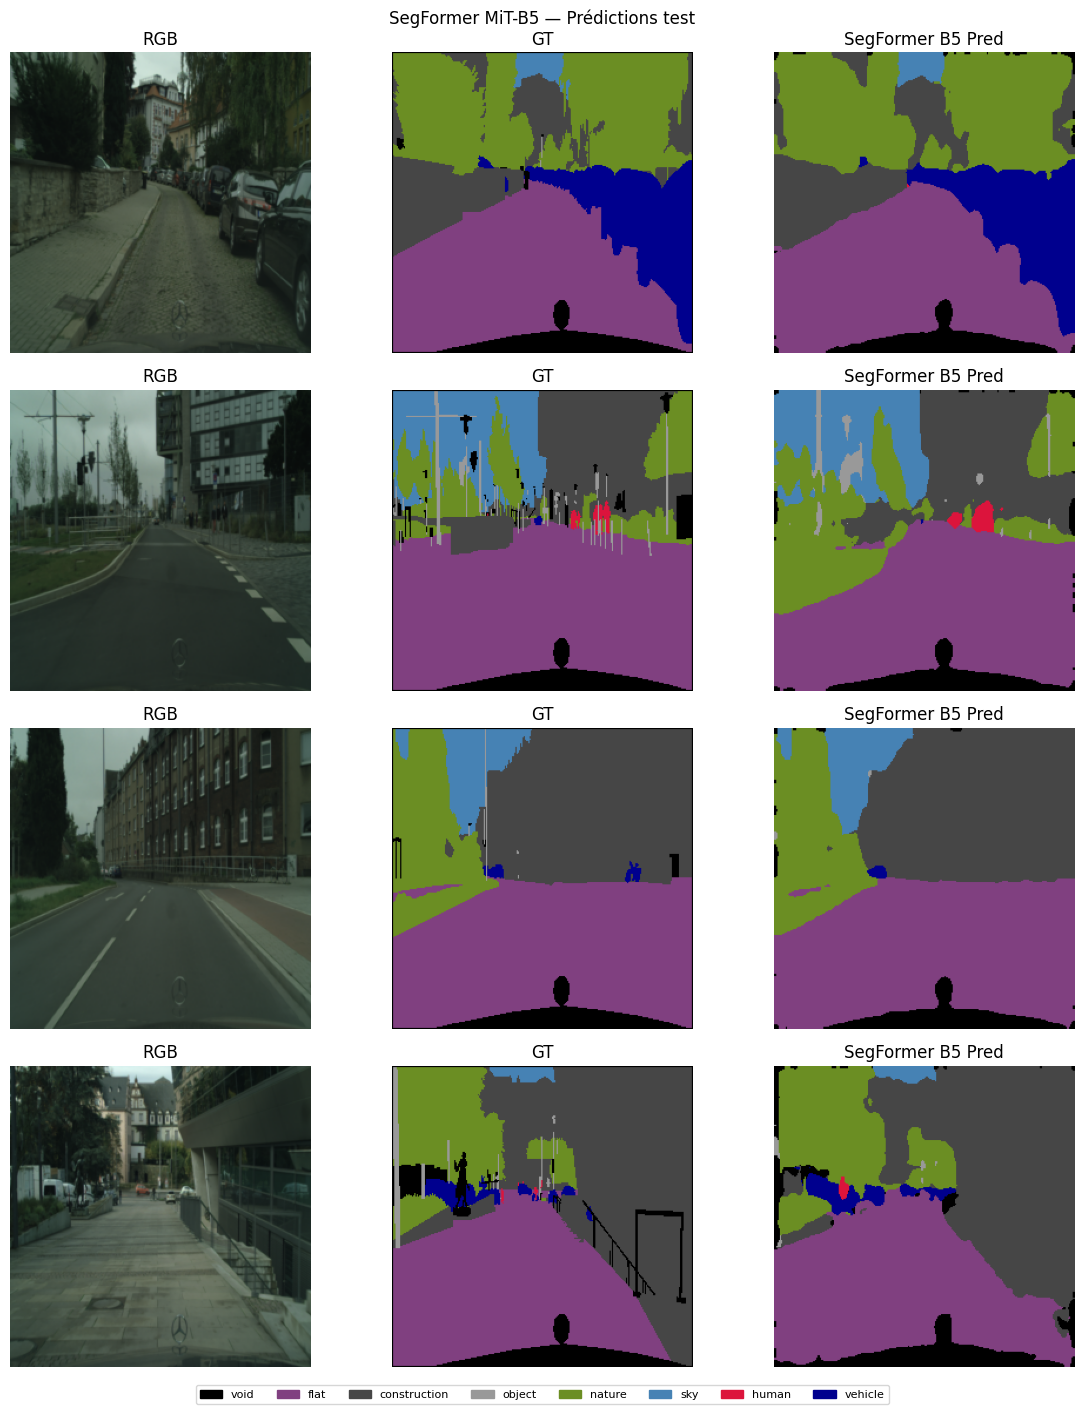

In [14]:
from PIL import Image as PILImage

def show_predictions(model, seq, n=4):
    X, y = seq[0]
    X, y = X[:n], y[:n]
    preds = np.argmax(model.predict(X, verbose=0), axis=-1)

    fig, axes = plt.subplots(n, 3, figsize=(12, n*3.5))
    for i in range(n):
        arr  = (X[i]*255).astype(np.uint8)
        gt_c = colorize_groups(PILImage.fromarray(y[i,...,0].astype(np.uint8)))
        pr_c = colorize_groups(PILImage.fromarray(preds[i].astype(np.uint8)))

        axes[i,0].imshow(arr);  axes[i,0].set_title("RGB")
        axes[i,1].imshow(gt_c); axes[i,1].set_title("GT")
        axes[i,2].imshow(pr_c); axes[i,2].set_title("SegFormer B5 Pred")
        for ax in axes[i]: ax.axis("off")

    patches = [mpatches.Patch(color=[c/255 for c in PALETTE[j]], label=CATEGORY_NAMES[j])
               for j in range(N_CLASSES)]
    fig.legend(handles=patches, loc="lower center", ncol=N_CLASSES,
               bbox_to_anchor=(0.5, -0.02), fontsize=8)
    plt.suptitle("SegFormer MiT-B5 — Prédictions test")
    plt.tight_layout()
    plt.savefig(str(OUT_DIR / f"{RUN_NAME}_preds.png"), dpi=100, bbox_inches="tight")
    plt.show()

show_predictions(model, test_seq)

## 💾 Sauvegarde des résultats


In [15]:
# Historique combiné
combined_hist = {}
for k in hist1.history:
    combined_hist[k] = hist1.history[k] + hist2.history.get(k, [])

results = {
    "run_name"       : RUN_NAME,
    "model"          : "segformer_mitb5",
    "encoder_preset" : ENCODER_PRESET,
    "framework"      : "tensorflow",
    "input_shape"    : list(SIZE_HW) + [3],
    "batch_size"     : BATCH,
    "best_path"      : str(BEST_PATH),
    "train_time_sec" : float(t_tot),
    "epochs_phase1"  : len(hist1.history["loss"]),
    "epochs_phase2"  : len(hist2.history["loss"]),
    "val_loss"       : float(val_res[0]),
    "val_mIoU"       : float(val_res[1]),
    "test_loss"      : float(test_res[0]),
    "test_mIoU"      : float(test_res[1]),
    "per_class_iou"  : {CATEGORY_NAMES[i]: round(per_class_iou[i], 4) for i in range(N_CLASSES)},
    "history"        : {k: [float(v) for v in vals] for k, vals in combined_hist.items()},
}

with open(RESULTS_JSON, "w") as f:
    json.dump(results, f, indent=2)
print(f"Résultats → {RESULTS_JSON}")

print(f"\n{'='*50}")
print(f"  SegFormer MiT-B5")
print(f"{'='*50}")
print(f"  Val  mIoU : {results['val_mIoU']:.4f}")
print(f"  Test mIoU : {results['test_mIoU']:.4f}")
print(f"  Durée     : {t_tot/60:.1f} min")

Résultats → /home/ui/PROJ9/out/experiments/SEGFORMER_MITB5_256x256_b4_aug1_rep1_ce_dice_e10ft5_seed42_results.json

  SegFormer MiT-B5
  Val  mIoU : 0.7213
  Test mIoU : 0.7364
  Durée     : 148.4 min
